# Проект спринта 16. Предсказание стоимости автомобиля на вторичном рынке с учётом бизнес-рисков.
### Цель
Разработать модель, которая будет предсказывать стоимость автомобиля на вторичном рынке на основании его описания в виде предопределенного набора прзнаков. Необходимо максимизировать прибыль и минимизировать убытки, для чего надо найти баланс между долей переплат и упущенной выгодой.

### Постановка задачи в терминах машинного обучения
- Тип задачи машинного обучения: регрессия, тип целевой переменной - `float`.
- Целевая переменная - стоимость автомобиля в рублях.
- Модели машинного обучения - градиентный бустинг на основе деревьев решений (реализации в библиотеках XGBoost, CatBoost, LightGBM).
- Необходимо выбрать лучшую реализацию модели с использованием технических и бизнес-метрик.
- Основные метрики - MAE, MSE, $R^2$. Бизнес-метрики - Overpricing Rate для переоценки более 20%, Underpricing Loss для недооценок более 20%.
- Для подбора оптимального набора гиперпараметров следует использовать байесовскую оптимизацию.
- Для интерпретации модели по важности признаков следует использовать SHAP.
- Необходимо обеспечить воспроизводимость результатов при помощи указания фиксированного значения `random_state`.

### Задачи
1. Загрузка обучающего и тестового датасетов.
2. Исследовательский анализ данных.
3. Предобработка данных для машинного обучения, формирование обучающей и валидационной выборок.
4. Обучение базовых моделей градиентного бустинга XGBoost, CatBoost, LightGBM с параметрами по умолчанию, их сравнение по техническим и бизнес-метрикам.
5. Подбор гиперпараметров для всех реализаций градиентного бустинга при помощи библиотеки Optuna с использованием валидационной выборки.
6. Интерпретация результатов лучшей модели на валидационной выборке: оценка важности признаков, подсчёт доли Overpricing Rate, Underpricing Loss, выявление особенности поведения модели в зависимости от марки автомобиля и региона.
7. Пррверка модели на тестовом датасете.
8. Формулировка выводов и рекомендаций по дальнейшему использованию модели.

### Описание данных

| **Признак**        | **Описание**                                                        | **Значимость для бизнеса**                                       |
| ------------------ | ------------------------------------------------------------------- | ---------------------------------------------------------------- |
| brand              | Марка автомобиля                                                    | Фундамент цены: престиж и надёжность бренда.                     |
| make_year          | Год выпуска                                                         | Главный счётчик амортизации: чем старше автомобиль, тем дешевле. |
| mileage_kmpl       | Пробег (км)                                                         | Реальный физический износ автомобиля.                            |
| engine_cc          | Объём двигателя (в кубических см)                                   | Влияет на мощность, налоги и интерес покупателей.                |
| fuel_type          | Тип топлива                                                         | Экономичность против мощности. Важный фактор ликвидности.        |
| transmission       | Тип коробки передач                                                 | «Автомат» или «механика» — ключевой фактор комфорта.             |
| owner_count        | Количество владельцев по ПТС                                        | Юридическая чистота и аккуратность эксплуатации.                 |
| color              | Цвет автомобиля                                                     | Психологический фактор: популярные цвета продаются быстрее.      |
| service_history    | Наличие сервисной книжки                                            | Подтверждает, что за машиной ухаживали вовремя.                  |
| accidents_reported | Количество зафиксированных ДТП                                      | Сильно бьёт по цене и безопасности будущей сделки.               |
| insurance_valid    | Действительна ли страховка                                          | Снижает первичные расходы покупателя после сделки.               |
| region             | Макрорегион РФ, в котором продаётся автомобиль (Москва, Сибирь, Юг) | Позволяет модели учитывать региональную специфику цен.           |
| price_rub          | Целевой признак: рыночная стоимость автомобиля в рублях             | Реальная сумма сделки, которую нужно предсказать.                |

## 1. Подготовка среды и загрузка данных
### 1.1. Установка библиотек

In [1]:
%pip install scikit-learn
%pip install -q --upgrade seaborn
%pip install -q --upgrade jinja2
%pip install -q phik
%pip install -q optuna
%pip install -q joblib
%pip install -q xgboost
%pip install -q lightgbm
%pip install -q catboost
%pip install -q shap

# Сохраним версии библиотек в requirements.txt
%pip freeze > requirements.txt


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgr

### 1.2. Импорт необходимых библиотек

In [2]:
import os
import math
import time
from urllib.request import urlopen

# Библиотеки для вычислений и работы с датасетами
import pandas as pd
import numpy as np
import phik

# Библиотеки машинного обучения
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import r2_score, mean_absolute_percentage_error, \
    mean_absolute_error, root_mean_squared_error, make_scorer
from sklearn.base import clone

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Подбор гиперпараметров
import optuna

# Оценка важности признаков
import shap

# Библиотеки для построения графиков
import seaborn as sns
import matplotlib.pyplot as plt

# Сериализация пайплайна
import joblib

# Для форматирования в HTML
from IPython.display import display, HTML, Markdown

/Users/texnhmakph/Projects/Yandex DS/ds-yandex/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1.3. Загрузка данных

In [3]:
# Константы и общие настройки
RANDOM_SEED = 42

# Лимит опасной переоценки
OVERPRICE_LIMIT = 0.2

# Лимит упущенной выгоды
UNDERPRICE_LIMIT = 0.2

pd.options.display.float_format = '{:.4f}'.format

BASE_URL = "https://code.s3.yandex.net/"

def load_dataset(file_name, **kwargs):
    try:
        if os.path.exists(file_name):
            return pd.read_csv(file_name, **kwargs)
        else:
            return pd.read_csv(BASE_URL + file_name, **kwargs)
    except:
        print("Ошибка загрузки датасета")
        raise

def show_dataset_info(df, title):
    display(HTML(f"<h2>{title}</h2>"))
    display(df.info())
    display(df.head())
    display(HTML("<h3>Числовые параметры</h3>"))
    display(df.select_dtypes(include='number').describe())
    display(HTML("<h3>Кардинальность категориальных параметров</h3>"))
    display(df.select_dtypes(include='str').nunique())

df_train = load_dataset("datasets/ds_s16_train_data.csv")
df_test = load_dataset("datasets/ds_s16_test_data.csv")

show_dataset_info(df_train, "Обучающий датасет")
show_dataset_info(df_test, "Тестовый датасет")

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           8000 non-null   int64  
 1   mileage_kmpl        8000 non-null   float64
 2   engine_cc           8000 non-null   int64  
 3   fuel_type           8000 non-null   str    
 4   owner_count         8000 non-null   int64  
 5   brand               8000 non-null   str    
 6   transmission        8000 non-null   str    
 7   color               8000 non-null   str    
 8   service_history     8000 non-null   str    
 9   accidents_reported  8000 non-null   int64  
 10  insurance_valid     8000 non-null   str    
 11  price_rub           8000 non-null   int64  
 12  region              8000 non-null   str    
dtypes: float64(1), int64(5), str(7)
memory usage: 812.6 KB


None

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2002,9.7000,1800,Diesel,2,Hyundai,Manual,Silver,Partial,0,No,242073,Урал
1,2004,16.1000,1500,Diesel,3,Hyundai,Manual,Black,Unknown,0,No,426029,Москва
2,2005,10.5100,5000,Diesel,2,Ford,Manual,Gray,Full,0,No,727050,Юг
3,2019,14.2700,2000,Petrol,5,Hyundai,Manual,White,Full,1,Yes,753168,Дальний Восток
4,2015,21.7200,1000,Petrol,1,Toyota,Automatic,Black,Full,0,Yes,733390,Сибирь


,make_year,mileage_kmpl,engine_cc,owner_count,accidents_reported,price_rub
count,8000.0000,8000.0000,8000.0000,8000.0000,8000.0000,8000.0000
mean,2009.2213,17.9463,2289.6875,3.0011,0.4879,683647.8721
std,8.3887,5.0156,1289.8121,1.4192,0.6938,264923.4986
min,1995.0000,5.0000,800.0000,1.0000,0.0000,95000.0000
25%,2002.0000,14.5300,1200.0000,2.0000,0.0000,493857.0000
50%,2009.0000,17.9700,2000.0000,3.0000,0.0000,663866.0000
75%,2017.0000,21.3500,3000.0000,4.0000,1.0000,855056.0000
max,2023.0000,35.0000,5000.0000,5.0000,5.0000,1676525.0000


fuel_type           3
brand              10
transmission        2
color               6
service_history     3
insurance_valid     2
region              6
dtype: int64

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           2000 non-null   int64  
 1   mileage_kmpl        2000 non-null   float64
 2   engine_cc           2000 non-null   int64  
 3   fuel_type           2000 non-null   str    
 4   owner_count         2000 non-null   int64  
 5   brand               2000 non-null   str    
 6   transmission        2000 non-null   str    
 7   color               2000 non-null   str    
 8   service_history     2000 non-null   str    
 9   accidents_reported  2000 non-null   int64  
 10  insurance_valid     2000 non-null   str    
 11  price_rub           2000 non-null   int64  
 12  region              2000 non-null   str    
dtypes: float64(1), int64(5), str(7)
memory usage: 203.3 KB


None

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2015,12.0900,5000,Diesel,1,Nissan,Automatic,White,Full,2,No,1213351,Москва
1,2016,14.0300,800,Petrol,4,Chevrolet,Manual,White,Partial,0,Yes,586881,Дальний Восток
2,2005,20.4000,2000,Petrol,1,Kia,Manual,Blue,Full,2,Yes,650752,Сибирь
3,1996,25.0900,800,Diesel,3,Volkswagen,Manual,Silver,Full,0,Yes,320452,Урал
4,1995,19.2500,5000,Diesel,5,Hyundai,Automatic,Black,Partial,0,No,694911,СПб


,make_year,mileage_kmpl,engine_cc,owner_count,accidents_reported,price_rub
count,2000.0000,2000.0000,2000.0000,2000.0000,2000.0000,2000.0000
mean,2009.1495,18.0184,2276.9000,3.0130,0.5095,675791.9355
std,8.3161,5.0658,1297.3928,1.4180,0.6951,268019.5989
min,1995.0000,5.0000,800.0000,1.0000,0.0000,95000.0000
25%,2002.0000,14.5700,1200.0000,2.0000,0.0000,481477.0000
50%,2009.0000,18.0050,1800.0000,3.0000,0.0000,649284.0000
75%,2016.0000,21.3825,3000.0000,4.0000,1.0000,845969.5000
max,2023.0000,34.3800,5000.0000,5.0000,4.0000,1629774.0000


fuel_type           3
brand              10
transmission        2
color               6
service_history     3
insurance_valid     2
region              6
dtype: int64

- Датасеты содержат 8000 и 2000 записей, пропуски отсутствуют. 
- Целевая переменная имеет целый тип (`int64`).
- Категориальные признаки имеют строковый тип, числовые - `int64` и `float64`.

## 2. Исследовательский анализ данных
- Опишем функции для построения диаграмм:

In [4]:
# Функция для построения гистограммы и боксплота на одной шкале
def draw_double_diag(data, title, x, xlabel, ylabel, hue=None, stat='count', figsize=(12, 6), bins='auto', kde=True, **kwargs):
    fig, (ax_hist, ax_box) = plt.subplots(
        nrows=2,
        ncols=1,
        sharex=True,
        figsize=figsize,
        gridspec_kw={'height_ratios': [2, 1]}
    )

    sns.boxplot(data=data,
                ax=ax_box,
                x=x, 
                hue=hue, 
                showmeans=True,
                legend=False,
                meanprops={
                    "marker": "o",
                    "markerfacecolor": "white",
                    "markeredgecolor": "black",
                    "markersize": 8
                })

    ax_box.set_xlabel(xlabel)  # Убираем подпись оси X, чтобы не дублировалась
    ax_box.set_ylabel('')  # Убираем подпись оси Y
    ax_box.set_yticks([])  # Убираем тики оси Y (они не нужны)

    sns.histplot(data=data,
                ax=ax_hist,
                x=x,
                hue=hue,
                kde=kde,
                bins=bins,
                stat=stat,
                **kwargs)

    # ax_hist.set_xlabel(xlabel)
    ax_hist.set_ylabel(ylabel)
    
    fig.suptitle(title, fontsize=14)

    plt.tight_layout()
    plt.show()

# Функция для построения гистограммы в сетке
def draw_histogram_in_grid(data,
                        field,
                        title,
                        xlabel, 
                        ylabel,
                        **kwargs):
    sns.histplot(data=data,
                x=field,
                 **kwargs)

    # plt.xticks(np.arange(0, 1300, step=50), rotation=90)
    kwargs['ax'].set_title(title)
    kwargs['ax'].set_xlabel(xlabel)
    kwargs['ax'].set_ylabel(ylabel)

def show_histogram_grid(features_desc, title, n_columns=2, **kwargs):
    n_lines = math.ceil(len(features_desc) / n_columns)
    _, axes = plt.subplots(n_lines, n_columns, 
                         figsize=(12, n_lines * 3))
    axes = axes.flatten()
    for i, (key, value) in enumerate(features_desc.items()):
        draw_histogram_in_grid(
                value['data'],
                key,
                value['title'] if 'title' in value else key, 
                value['xlabel'] if 'xlabel' in value else "Значение", 
                value['ylabel'] if 'ylabel' in value else "Количество", 
                ax=axes[i],
                **kwargs
                )

    plt.suptitle(title, fontsize=16, y=1)
    plt.tight_layout()
    plt.show()

# Функция для построения столбчатой диаграммы в сетке
def draw_barplot_grid(series, 
                 title, 
                 xlabel, 
                 ylabel, 
                 rot=0, 
                 vertical=True, 
                 mean=None,
                 **kwargs):
    series.head(20).plot(
        title=title,
        kind='bar' if vertical else 'barh',
        xlabel=xlabel if vertical else ylabel,
        ylabel=ylabel if vertical else xlabel,
        grid=True,
        rot=rot,
        **kwargs)
    
    # kwargs['ax'].legend(bbox_to_anchor=(1, 1))
    
    if mean != None:
        if vertical:
            kwargs['ax'].axhline(mean, color='red', linestyle='--')
        else:
            kwargs['ax'].axvline(mean, color='red', linestyle='--')   

def show_barplot_grid(features_desc, title, n_columns=2, **kwargs):
    n_lines = round(len(features_desc) / n_columns)
    _, axes = plt.subplots(n_lines, n_columns, 
                         figsize=(12, n_lines * 5))
    axes = axes.flatten()
    for i, value in enumerate(features_desc):
        draw_barplot_grid(
                value['data'],
                value['title'], 
                value['xlabel'] if 'xlabel' in value else "Значение", 
                value['ylabel'] if 'ylabel' in value else "Количество", 
                value.get('rot'),
                value['vertical'] if 'vertical' in value else True,
                value.get('mean'),
                ax=axes[i],
                **kwargs
                )

    plt.suptitle(title, fontsize=16, y=1)
    plt.tight_layout()
    plt.show()

# Функция для построения скаттерплота в сетке
def draw_scatterplot_in_grid(data, 
                     x, 
                     y, 
                     title,
                     xlabel, 
                     ylabel,
                     **kwargs):
    sns.scatterplot(data=data, 
                    x=x,
                    y=y,
                    **kwargs)
    kwargs['ax'].set_title(title)
    kwargs['ax'].set_xlabel(xlabel)
    kwargs['ax'].set_ylabel(ylabel)

def show_scatterplot_grid(df, features_desc, title, n_columns=2, **kwargs):
    n_lines = round(len(features_desc) / n_columns)
    _, axes = plt.subplots(n_lines, n_columns, 
                         figsize=(12, n_lines * 4))
    axes = axes.flatten()
    for i, (key, value) in enumerate(features_desc.items()):
        draw_scatterplot_in_grid(
                df,
                key[0],
                key[1],
                value['title'] if 'title' in value else "/".join(key), 
                value['xlabel'] if 'xlabel' in value else key[0], 
                value['ylabel'] if 'ylabel' in value else key[1], 
                ax=axes[i],
                **kwargs
                )

    plt.suptitle(title, fontsize=16, y=1)
    plt.tight_layout()
    plt.show()

# Функция для построения тепловой карты
def draw_heatmap(df, title, figsize=(14,14), font_scale=0.6):
    plt.figure(figsize=figsize)
    plt.title(title)
    sns.set_theme(font_scale=font_scale)
    sns.heatmap(data=df, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()

def draw_barplot(series, 
                 title, 
                 xlabel, 
                 ylabel, 
                 rot=0, 
                 vertical=True, 
                 mean=None):
    series.plot(
        title=title,
        kind='bar' if vertical else 'barh',
        figsize=(8, 4) if vertical else (12, 4),
        xlabel=xlabel if vertical else ylabel,
        ylabel=ylabel if vertical else xlabel,
        grid=True,
        rot=rot)
    
    if mean != None:
        if vertical:
            plt.axhline(mean, color='red', linestyle='--')
        else:
            plt.axvline(mean, color='red', linestyle='--')
    plt.show()

def draw_qqplot_in_grid(data1, 
                        data2,
                        title,
                        xlabel, 
                        ylabel,
                        **kwargs):
    q = np.linspace(0, 1, 100)
    data1_q = np.quantile(data1.dropna(), q)
    data2_q = np.quantile(data2.dropna(), q)

    ax = kwargs.pop('ax')
    ax.scatter(data1_q, data2_q, **kwargs)

    mn = min(data1.min(), data2.min())
    mx = max(data1.max(), data2.max())

    ax.plot([mn, mx], [mn, mx], linestyle='--', color='red')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

def show_qqplot_grid(data_desc, title, n_columns=2, **kwargs):
    n_lines = round(len(data_desc) / n_columns)
    _, axes = plt.subplots(n_lines, n_columns, 
                         figsize=(12, n_lines * 4))
    axes = axes.flatten()
    for i, value in enumerate(data_desc):
        draw_qqplot_in_grid(
                value['data1'],
                value['data2'],
                value['title'], 
                value['xlabel'], 
                value['ylabel'], 
                ax=axes[i],
                **kwargs
                )

    plt.suptitle(title, fontsize=16, y=1)
    plt.tight_layout()
    plt.show()    

- Разделим признаки на числовые и категориальные

In [5]:
target = 'price_rub'

num_features = df_train.select_dtypes(include='number').drop(columns=target).columns.to_list()
cat_features = df_train.select_dtypes(include='str').columns.to_list()
display(num_features)

['make_year', 'mileage_kmpl', 'engine_cc', 'owner_count', 'accidents_reported']

### 2.1. Распределение целевой переменной
- Построим диаграмму распределения целевой переменной:

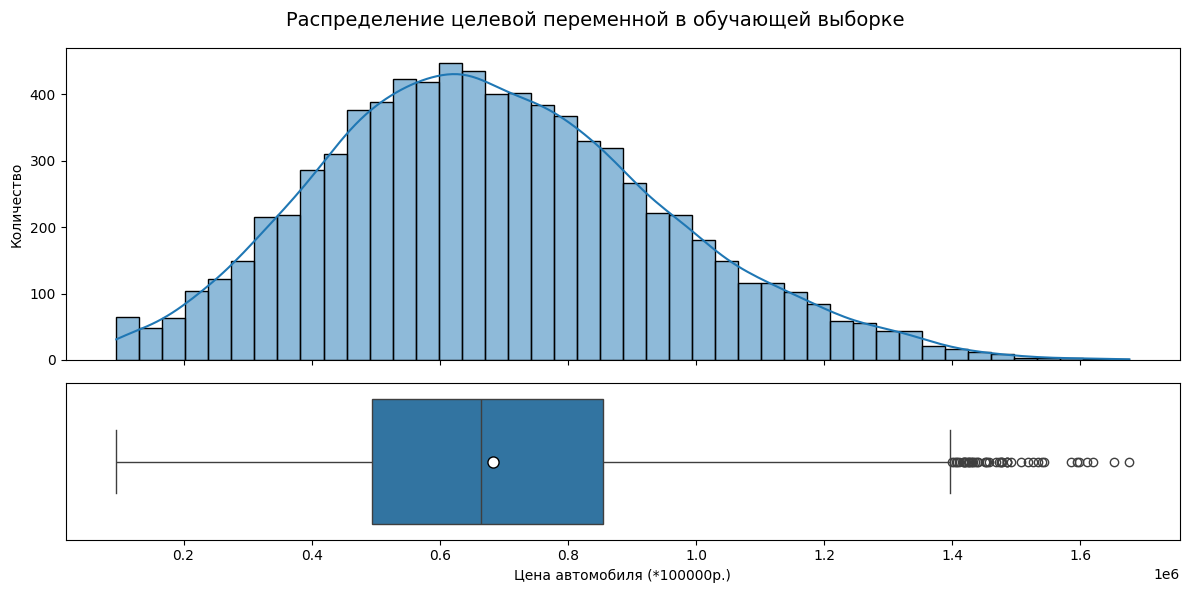

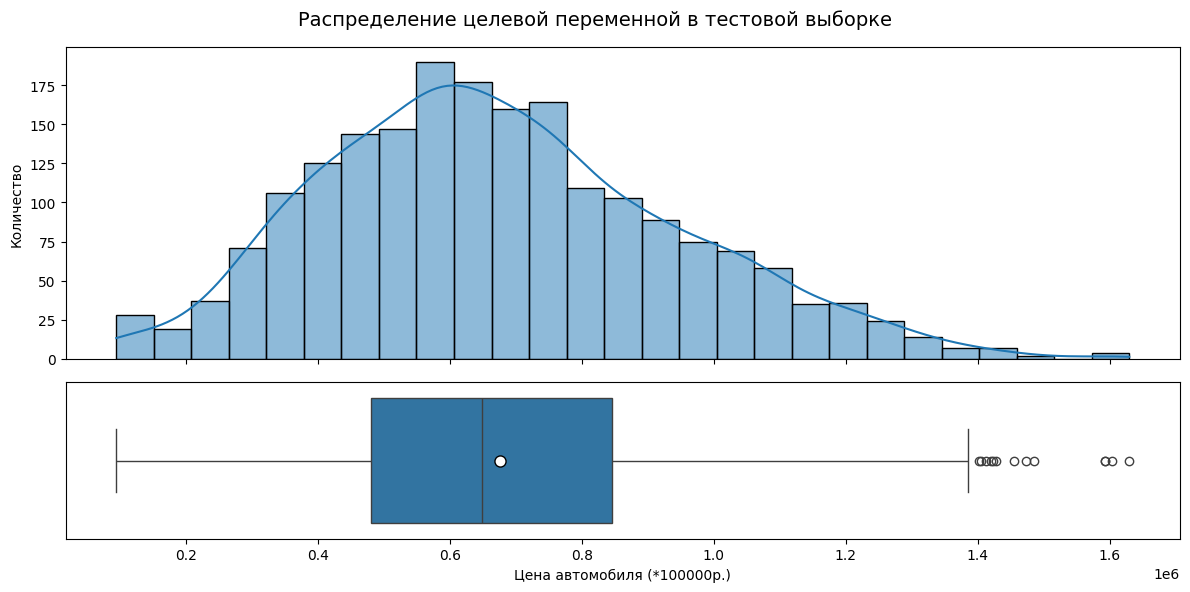

In [6]:
draw_double_diag(df_train, "Распределение целевой переменной в обучающей выборке", target, 
                 "Цена автомобиля (*100000р.)", "Количество")

draw_double_diag(df_test, "Распределение целевой переменной в тестовой выборке", target, 
                 "Цена автомобиля (*100000р.)", "Количество")

- Целевая переменная распределена одинаково в обучающей и тестовой выборках.
- Распределение - нормальное, правый хвост немного тяжелее. Выбросы с ценой более 1.4 млн. руб. не являются аномалиями.

- Построим скаттерплоты зависимости целевой переменной от числовых признаков:

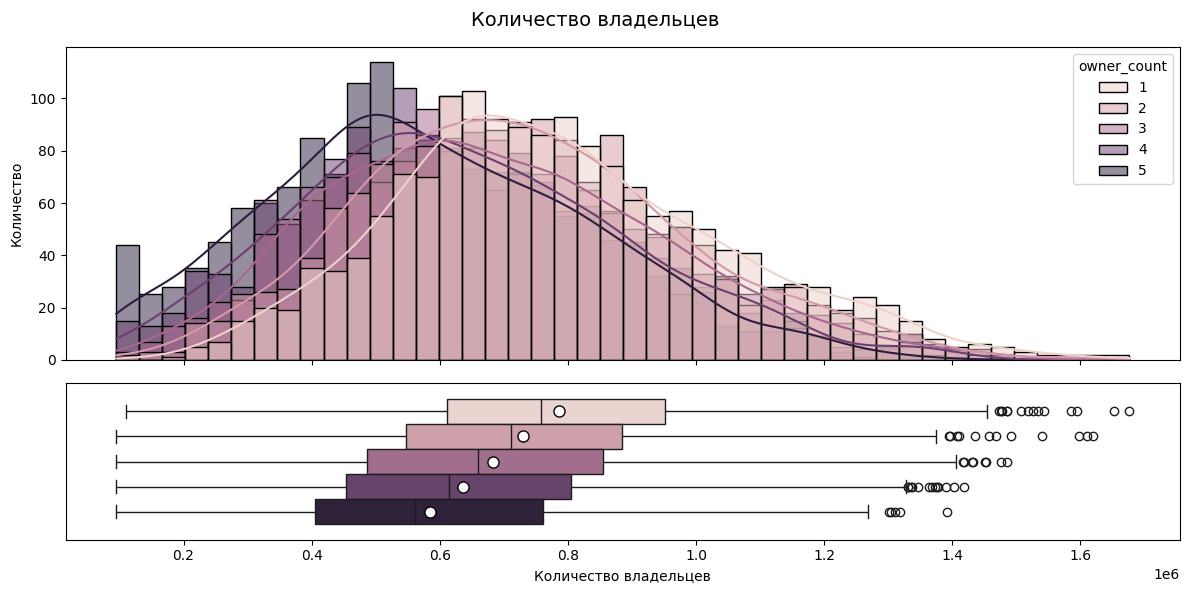

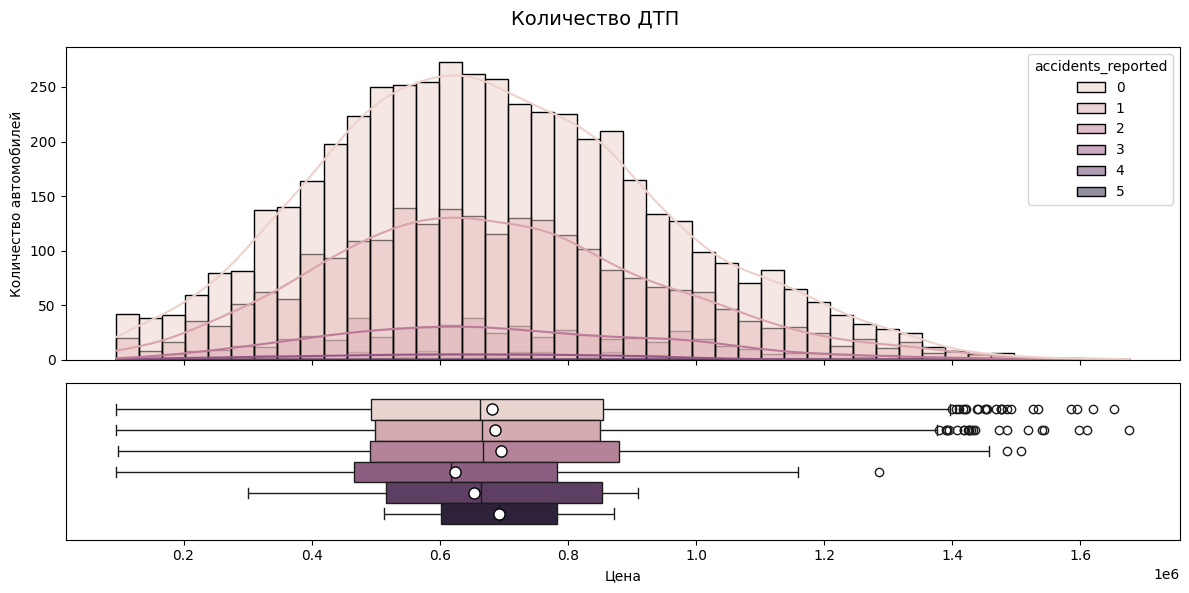

In [7]:
draw_double_diag(df_train, "Количество владельцев", target, "Количество владельцев", "Количество", 'owner_count')
draw_double_diag(df_train, "Количество ДТП", target, "Цена", "Количество автомобилей", 'accidents_reported')

num_features_desc = {
    # 'make_year': {'data': df_train, 'title': "Год выпуска", 'xlabel': "Год"},
    'mileage_kmpl': {'data': df_train, 'title': "Пробег", 'xlabel': "Пробег (тыс. км)"}
    # 'engine_cc': {'data': df_train, 'title': "Объём двигателя", 'xlabel': "Объём (куб. см)"},
    # 'owner_count': {'data': df_train, 'title': "Количество владельцев", 'xlabel': "Количество"},
    # 'accidents_reported': {'data': df_train, 'title': "Количество ДТП", 'xlabel': "Количество"}
}


- Подтверждается очевидная обратная зависимость цены от количества владельцев.
- Неожиданно слабо на цену влияет количество ДТП - медиана и средняя цена машин, побывавших в ДТП, примерно такие же, как у не битых.

### 2.2. Исследование корреляции признаков
- Отобразим корреляцию целевой переменной с признаками:

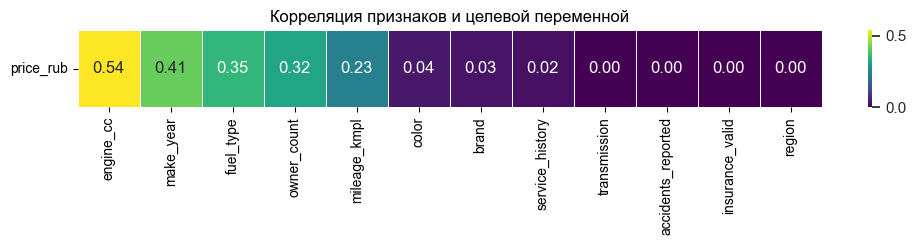

In [8]:
phik_matrix = phik.phik_matrix(df_train, interval_cols=['mileage_kmpl', 'engine_cc', target])

draw_heatmap((phik_matrix.loc[[target]]
               .drop(columns=target)
               .T
               .sort_values(by=target, ascending=False)
               .T), "Корреляция признаков и целевой переменной", figsize=(12, 1), font_scale=1)

- Отобразим корреляцию признаков друг с другом:

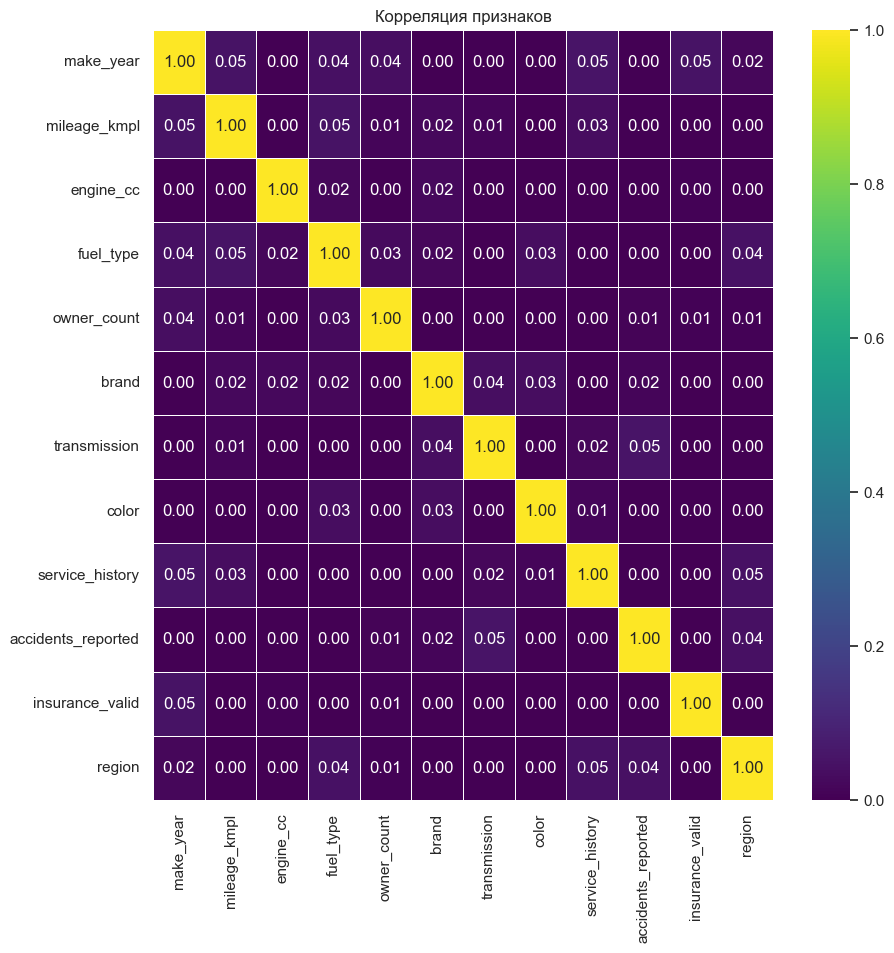

In [9]:
draw_heatmap(phik_matrix.drop(columns=target).drop(index=target), "Корреляция признаков",
             figsize=(10, 10), font_scale=1)

- Цена в наибольшей степени зависит от объёма двигателя и года выпуска.
- Признаки практически не коррелируют друг с другом.

## 3. Предобработка данных
### 3.1. Преобразование типов
- Преобразуем типы категориальных признаков к `category` и напишем соответствующую функцию:

In [10]:
def convert_categorical(df):
    cat_features = df.select_dtypes(include='str').columns.to_list()
    df_new = df.copy()
    df_new[cat_features] = df[cat_features].astype('category')
    return df_new

df_train_pp = convert_categorical(df_train)
display(df_train_pp.info())

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   make_year           8000 non-null   int64   
 1   mileage_kmpl        8000 non-null   float64 
 2   engine_cc           8000 non-null   int64   
 3   fuel_type           8000 non-null   category
 4   owner_count         8000 non-null   int64   
 5   brand               8000 non-null   category
 6   transmission        8000 non-null   category
 7   color               8000 non-null   category
 8   service_history     8000 non-null   category
 9   accidents_reported  8000 non-null   int64   
 10  insurance_valid     8000 non-null   category
 11  price_rub           8000 non-null   int64   
 12  region              8000 non-null   category
dtypes: category(7), float64(1), int64(5)
memory usage: 430.2 KB


None

### 3.2. Разделение на обучающую и валидационную выборки
- Выделим из обучающего датасета валидационную выборку:

In [11]:
X = df_train.drop(columns=[target])
y = df_train[target]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=RANDOM_SEED)

print(f"Размеры выборок: {len(X_train)}, {len(X_val)}")

Размеры выборок: 6000, 2000


### 3.3. Создание пайплайнов предобработки
- Создадим пайплайны предобработки для разных библиотек: для XGBoost закодируем категориальные признаки при помощи One-hot encoding, для других библиотек преобразуем к типу `category`.

In [12]:
xgb_preprocess = ColumnTransformer(transformers=[
    ('cat_conv', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_features)
], remainder='passthrough')
xgb_preprocess.set_output(transform='pandas')

cat_preprocess = ColumnTransformer(transformers=[
    ('cat_conv', FunctionTransformer(convert_categorical), cat_features)
], remainder='passthrough')
cat_preprocess.set_output(transform='pandas');

## 4. Обучение базовых моделей

- Функции для вычисления метрик и построения графика обучения:

In [13]:
def overpricing_rate(y_test, y_pred, threshold=0.2):
    error_ratio = (y_pred - y_test) / y_test
    return (error_ratio > threshold).mean()

def underpricing_rate(y_test, y_pred, threshold=-0.2):
    error_ratio = (y_pred - y_test) / y_test
    return (error_ratio < threshold).mean()

def underpricing_loss(y_test, y_pred, threshold=-0.2):
    error_ratio = (y_pred - y_test) / y_test
    under_mask = error_ratio < threshold
    return (y_test[under_mask] - y_pred[under_mask]).sum()

def calc_metrics(y_test, y_pred, prefix=""):
    return pd.Series({'MAE': mean_absolute_error(y_test, y_pred),
                      'MAPE': mean_absolute_percentage_error(y_test, y_pred),
                      'RMSE': root_mean_squared_error(y_test, y_pred),
                      'R2': r2_score(y_test, y_pred),
                      'Overpricing Rate': overpricing_rate(y_test, y_pred),
                      'Underpricing Rate': underpricing_rate(y_test, y_pred),
                      'Underpricing Loss': underpricing_loss(y_test, y_pred)
                      })
# Строим график
def draw_cv_plot(results, title, metric, learn_key, test_key, ylabel):
    epochs = len(results[learn_key][metric])
    x = range(epochs)
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.plot(x, results[learn_key][metric], label='MAE на обучающей выборке')
    plt.plot(x, results[test_key][metric], label='MAE на валидационной выборке')
    plt.xlabel('Кол-во итераций (n_estimators)')
    plt.ylabel(ylabel)
    plt.show()

### 4.1. Обучение `XGBRegressor`

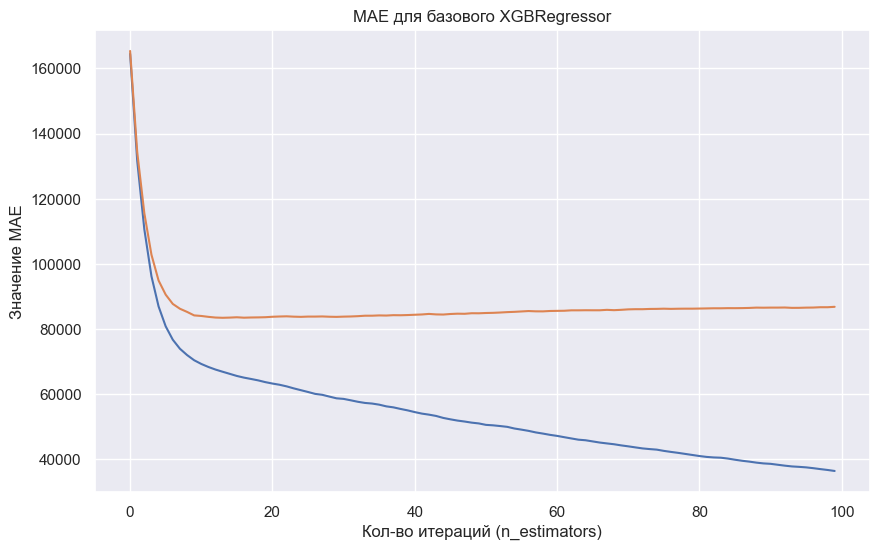

MAE                    86801.1016
MAPE                       0.1614
RMSE                  107978.2266
R2                         0.8346
Overpricing Rate           0.1475
Underpricing Rate          0.0960
Underpricing Loss   33074683.4375
Fit time                   0.1717
Predict time:              0.0038
dtype: float64

In [14]:
# Предобработка выборок
xgb_pp = clone(xgb_preprocess)
xgb_pp.fit(X_train)
X_xgb_train_pp = xgb_pp.transform(X_train)
X_xgb_val_pp = xgb_pp.transform(X_val)

xgb_base_model = XGBRegressor(random_state=RANDOM_SEED, eval_metric='mae')
xgb_start_time = time.perf_counter()

# Обучаем модель без пайплайна
xgb_base_model.fit(X_xgb_train_pp, y_train, 
                 eval_set=[(X_xgb_train_pp, y_train), (X_xgb_val_pp, y_val)],
                 verbose=False)

xgb_fit_time = time.perf_counter() - xgb_start_time

# Достаём значения метрики mae на каждой итерации обучения
xgb_results = xgb_base_model.evals_result()

draw_cv_plot(xgb_results, "MAE для базового XGBRegressor", "mae", 
             'validation_0', 'validation_1', "Значение MAE")

xgb_start_time = time.perf_counter()
y_pred_xgb_base = xgb_base_model.predict(X_xgb_val_pp)
xgb_predict_time = time.perf_counter() - xgb_start_time

xgb_base_metrics = pd.concat([calc_metrics(y_val, y_pred_xgb_base),
                              pd.Series({'Fit time': xgb_fit_time,
                                        'Predict time:': xgb_predict_time})])
display(xgb_base_metrics)

### 4.2. Обучение `CatBoostRegressor`

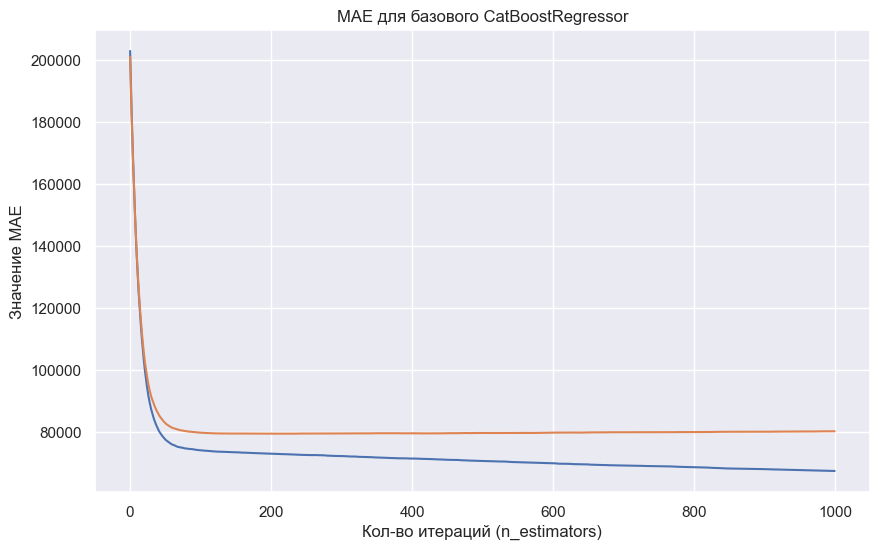

MAE                    79530.7240
MAPE                       0.1502
RMSE                   99196.9425
R2                         0.8604
Overpricing Rate           0.1370
Underpricing Rate          0.0700
Underpricing Loss   22919930.0137
Fit time                   1.8162
Predict time:              0.0016
dtype: float64

In [15]:
# Предобработка выборок
cb_pp = clone(cat_preprocess)
cb_pp.fit(X_train, y_train)
X_cat_train_pp = cb_pp.transform(X_train)
X_cat_val_pp = cb_pp.transform(X_val)
cat_features = X_cat_train_pp.select_dtypes(include='category').columns.to_list()

cb_base_model = CatBoostRegressor(random_state=RANDOM_SEED, eval_metric='MAE')

cat_start_time = time.perf_counter()
cb_base_model.fit(X_cat_train_pp, y_train, 
                 eval_set=[(X_cat_train_pp, y_train), (X_cat_val_pp, y_val)],
                 cat_features=cat_features,
                 verbose=False)
cb_fit_time = time.perf_counter() - cat_start_time

# Достаём значения метрики mae на каждой итерации обучения
cat_results = cb_base_model.get_evals_result()

draw_cv_plot(cat_results, "MAE для базового CatBoostRegressor", "MAE", 
             'validation_0', 'validation_1', "Значение MAE")

cb_start_time = time.perf_counter()
y_pred_cb_base = cb_base_model.predict(X_cat_val_pp)
cb_predict_time = time.perf_counter() - cb_start_time

y_pred_cb_base = cb_base_model.predict(X_cat_val_pp)
cb_base_metrics = pd.concat([calc_metrics(y_val, y_pred_cb_base),
                              pd.Series({'Fit time': cb_fit_time,
                                        'Predict time:': cb_predict_time})])
display(cb_base_metrics)

### 4.3. Обучение `LGBMRegressor`

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000889 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 347
[LightGBM] [Info] Number of data points in the train set: 6000, number of used features: 12
[LightGBM] [Info] Start training from score 682305.993000


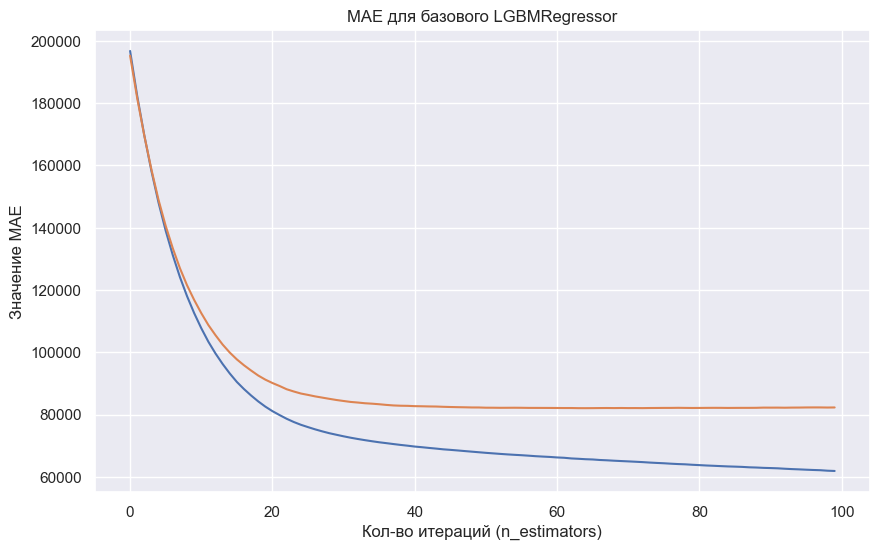

MAE                    82289.1877
MAPE                       0.1552
RMSE                  102267.5934
R2                         0.8516
Overpricing Rate           0.1390
Underpricing Rate          0.0755
Underpricing Loss   25030886.5386
Fit time                   0.4870
Predict time:              0.0030
dtype: float64

In [16]:
lgbm_base_model = LGBMRegressor(random_state=RANDOM_SEED)

lgbm_start_time = time.perf_counter()
lgbm_base_model.fit(X_cat_train_pp, y_train,
               eval_metric='mae',
               eval_set=[(X_cat_train_pp, y_train), (X_cat_val_pp, y_val)],
               categorical_feature=cat_features)

lgbm_fit_time = time.perf_counter() - lgbm_start_time
lgbm_results = lgbm_base_model.evals_result_

draw_cv_plot(lgbm_results, "MAE для базового LGBMRegressor", "l1", 
             'training', 'valid_1', "Значение MAE")

lgbm_start_time = time.perf_counter()
y_pred_lgbm_base = lgbm_base_model.predict(X_cat_val_pp)
lgbm_predict_time = time.perf_counter() - lgbm_start_time

y_pred_lgbm_base = lgbm_base_model.predict(X_cat_val_pp)
lgbm_base_metrics = pd.concat([calc_metrics(y_val, y_pred_lgbm_base),
                              pd.Series({'Fit time': lgbm_fit_time,
                                        'Predict time:': lgbm_predict_time})])
display(lgbm_base_metrics)

### 4.4. Сравнение моделей

In [17]:
display(pd.DataFrame({'XGBRegressor': xgb_base_metrics, 
                      'CatBoostRegressor': cb_base_metrics, 
                      'LGBMRegressor': lgbm_base_metrics}))

,XGBRegressor,CatBoostRegressor,LGBMRegressor
MAE,86801.1016,79530.7240,82289.1877
MAPE,0.1614,0.1502,0.1552
RMSE,107978.2266,99196.9425,102267.5934
R2,0.8346,0.8604,0.8516
Overpricing Rate,0.1475,0.1370,0.1390
Underpricing Rate,0.0960,0.0700,0.0755
Underpricing Loss,33074683.4375,22919930.0137,25030886.5386
Fit time,0.1717,1.8162,0.4870
Predict time:,0.0038,0.0016,0.0030


- Все три модели переобучаются: на валидационной выборке MAE сначала убывает, а потом остаётся на одном уровне или увеличивается (в случае `XGBRegressor`).
- Лучший результат получается с `CatBoostRegressor` - MAE около 80000 р. Эта модель обучается дольше остальных, но на предсказание тратит меньше времени.

### 4.5. `CatBoostRegressor` с квантильной регрессией

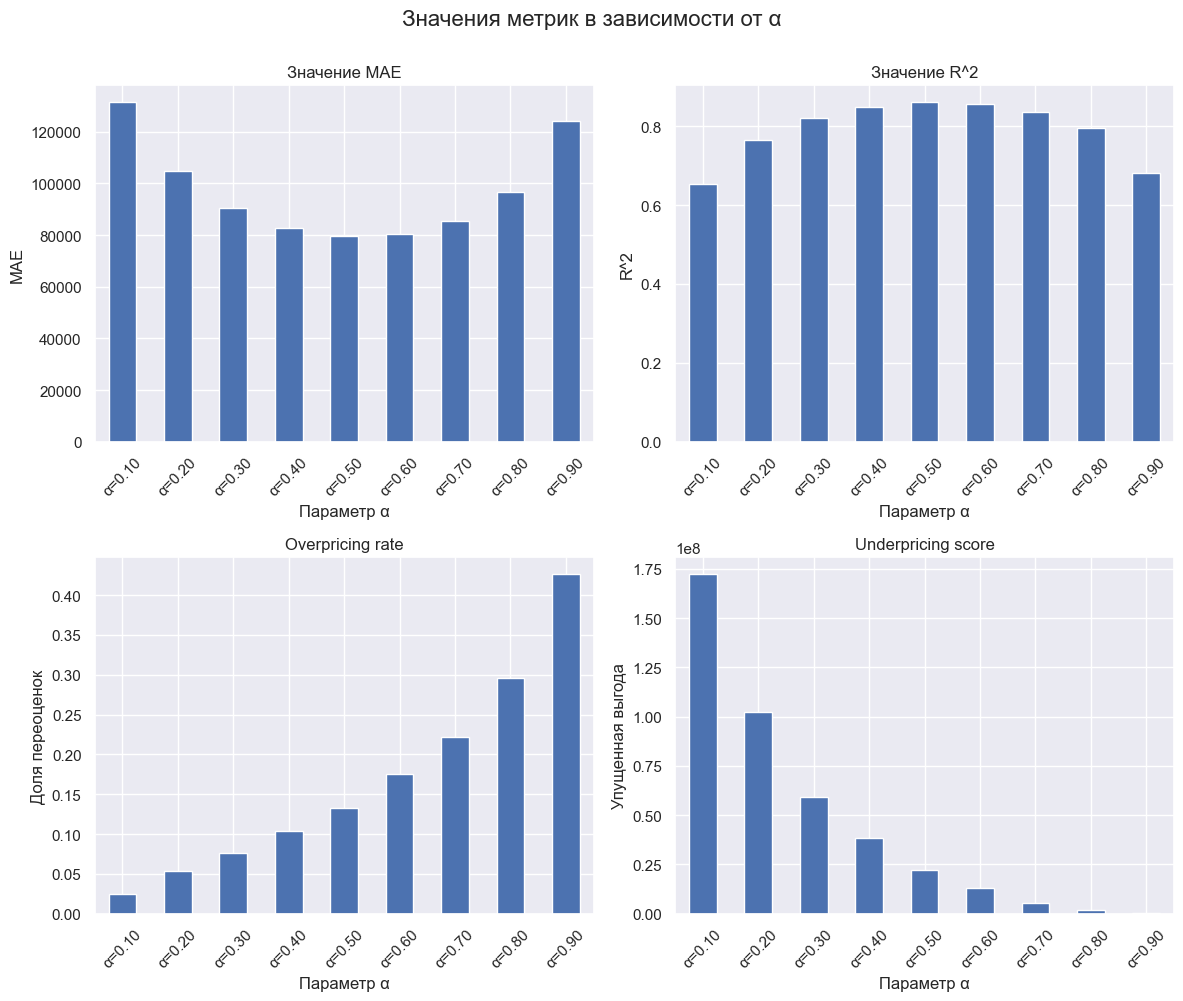

In [18]:
def evaluate_cbql(alpha=0.5):
    cbql_model = CatBoostRegressor(random_state=RANDOM_SEED, 
                                    eval_metric='MAE',
                                    loss_function=f'Quantile:alpha={alpha}')

    cbql_model.fit(X_cat_train_pp, y_train, 
                     cat_features=cat_features,
                     verbose=False)
    
    y_pred_cbql = cbql_model.predict(X_cat_val_pp)
    return calc_metrics(y_val, y_pred_cbql)

cbql_metrics = {}
for alpha in np.linspace(0.1, 0.9, 9):
    cbql_metrics[f"α={alpha:.2f}"] = evaluate_cbql(alpha)

cbql_metrics_df = pd.DataFrame(cbql_metrics).T
cbql_desc = [
    {'data': cbql_metrics_df['MAE'], 'title': "Значение MAE", 
     'xlabel': "Параметр α", 'ylabel': 'MAE', 'rot': 45},
    {'data': cbql_metrics_df['R2'], 'title': "Значение R^2", 
     'xlabel': "Параметр α", 'ylabel': 'R^2', 'rot': 45},
    {'data': cbql_metrics_df['Overpricing Rate'], 'title': "Overpricing rate", 
     'xlabel': "Параметр α", 'ylabel': 'Доля переоценок', 'rot': 45},
    {'data': cbql_metrics_df['Underpricing Loss'], 'title': "Underpricing score", 
     'xlabel': "Параметр α", 'ylabel': 'Упущенная выгода', 'rot': 45}
]

show_barplot_grid(cbql_desc, "Значения метрик в зависимости от α")

### 4.6. Выводы
- Все три базовые модели переобучаются: на валидационной выборке MAE сначала убывает, а потом остаётся на одном уровне или увеличивается (в случае `XGBRegressor`).
- Лучший результат получается с `CatBoostRegressor` - MAE около 80000 р. Бизнес-метрики этой модели также имеют лучшие значения. Эта модель обучается дольше остальных, но на предсказание тратит меньше времени.
- При использовании квантильной функции потерь с ростом параметра `alpha` Overpricing rate растёт, а Underpricing score убывает. Поскольку распределение целевой переменной нормальное симметричное, оптимальный баланс достигается на значении `alpha` 0.5, при котором квантильный лосс совпадает со стандартным MAE. Это подтверждается метриками MAE и R^2, которые достигают оптимальных значений при `alpha` 0.5.

## 5. Настройка гиперпараметров моделей

### 5.1. Подбор гиперпараметров `XGBRegressor`

In [19]:
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'eta': trial.suggest_float('eta', 0.01, 1, log=True),
        'gamma': trial.suggest_float('gamma', 1e-8, 1, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'random_state': RANDOM_SEED
    }

    xgb_model = XGBRegressor(**params)
    xgb_model.fit(X_xgb_train_pp, y_train)
    metrics = calc_metrics(y_val, xgb_model.predict(X_xgb_val_pp))

    trial.report(metrics['MAE'], step=0)
    if trial.should_prune():
        raise optuna.TrialPruned()

    return metrics['MAE']

sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)

xgb_study = optuna.create_study(direction="minimize", sampler=sampler) 
xgb_study.optimize(objective_xgb, n_trials=35, show_progress_bar=True) 

display(HTML("<h2>Лучшие гиперпараметры:</h2>"))
display(pd.Series(xgb_study.best_params))
display(HTML(f"<h2>Лучшее значение MAE: </h2>{xgb_study.best_value:8f}"))

[I 2026-06-17 07:38:00,377] A new study created in memory with name: no-name-382435b6-1f18-40ea-80f1-3524fc1ba2a0
Best trial: 0. Best value: 90691.6:   3%|▎         | 1/35 [00:02<01:25,  2.50s/it]

[I 2026-06-17 07:38:02,882] Trial 0 finished with value: 90691.6484375 and parameters: {'n_estimators': 1062, 'max_depth': 10, 'eta': 0.29106359131330695, 'gamma': 0.0006155564318973005, 'reg_alpha': 2.5361081166471375e-07}. Best is trial 0 with value: 90691.6484375.


Best trial: 1. Best value: 90635.9:   6%|▌         | 2/35 [00:03<00:44,  1.34s/it]

[I 2026-06-17 07:38:03,412] Trial 1 finished with value: 90635.921875 and parameters: {'n_estimators': 734, 'max_depth': 3, 'eta': 0.5399484409787432, 'gamma': 0.0006440507553993703, 'reg_alpha': 0.02358594058414266}. Best is trial 1 with value: 90635.921875.


Best trial: 1. Best value: 90635.9:   9%|▊         | 3/35 [00:04<00:41,  1.29s/it]

...

Best trial: 24. Best value: 79976.9:  97%|█████████▋| 34/35 [00:42<00:00,  1.10it/s]

[I 2026-06-17 07:38:43,235] Trial 33 pruned. 


Best trial: 24. Best value: 79976.9: 100%|██████████| 35/35 [00:43<00:00,  1.24s/it]

[I 2026-06-17 07:38:43,738] Trial 34 finished with value: 80426.2734375 and parameters: {'n_estimators': 696, 'max_depth': 3, 'eta': 0.048161978107652846, 'gamma': 4.573732751521164e-07, 'reg_alpha': 0.011288741904213249}. Best is trial 24 with value: 79976.890625.


n_estimators   1015.0000
max_depth         3.0000
eta               0.0179
gamma             0.0027
reg_alpha         0.0000
dtype: float64

### 5.2. Подбор гиперпараметров `CatBoostRegressor`

In [20]:
def objective_cb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        # 'rsm': trial.suggest_float('rsm', 0.5, 1),
        'random_state': RANDOM_SEED,
        # 'early_stopping_rounds': trial.suggest_int('early_stopping_rounds', 100, 2000),
        'verbose': 0
    }

    cb_model = CatBoostRegressor(**params)
    cb_model.fit(X_cat_train_pp, y_train, cat_features=cat_features)
    metrics = calc_metrics(y_val, cb_model.predict(X_cat_val_pp))

    trial.report(metrics['MAE'], step=0)
    if trial.should_prune():
        raise optuna.TrialPruned()

    return metrics['MAE']

sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)

cb_study = optuna.create_study(direction="minimize", sampler=sampler) 
cb_study.optimize(objective_cb, n_trials=35, show_progress_bar=True) 

display(HTML("<h2>Лучшие гиперпараметры:</h2>"))
display(pd.Series(cb_study.best_params))
display(HTML(f"<h2>Лучшее значение MAE: </h2>{cb_study.best_value:8f}"))

[I 2026-06-17 07:38:43,747] A new study created in memory with name: no-name-530329b9-d876-47e2-833a-64f3ad18d718
Best trial: 0. Best value: 86283.8:   3%|▎         | 1/35 [00:03<01:54,  3.37s/it]

[I 2026-06-17 07:38:47,114] Trial 0 finished with value: 86283.76750447966 and parameters: {'n_estimators': 1062, 'max_depth': 10, 'learning_rate': 0.29106359131330695, 'l2_leaf_reg': 6.387926357773329}. Best is trial 0 with value: 86283.76750447966.


Best trial: 1. Best value: 79650.3:   6%|▌         | 2/35 [00:04<00:58,  1.78s/it]

[I 2026-06-17 07:38:47,777] Trial 1 finished with value: 79650.33299883961 and parameters: {'n_estimators': 734, 'max_depth': 4, 'learning_rate': 0.01306673923805328, 'l2_leaf_reg': 8.795585311974417}. Best is trial 1 with value: 79650.33299883961.


Best trial: 1. Best value: 79650.3:   9%|▊         | 3/35 [00:06<01:13,  2.31s/it]

...

Best trial: 20. Best value: 79079.8:  97%|█████████▋| 34/35 [00:56<00:01,  1.32s/it]

[I 2026-06-17 07:39:40,498] Trial 33 pruned. 


Best trial: 20. Best value: 79079.8: 100%|██████████| 35/35 [00:58<00:00,  1.66s/it]

[I 2026-06-17 07:39:41,884] Trial 34 pruned. 


n_estimators    1797.0000
max_depth          3.0000
learning_rate      0.0119
l2_leaf_reg        1.7125
dtype: float64

### 5.3. Подбор гиперпараметров `LGBMRegressor`

In [21]:
def objective_lgbm(trial):

    max_depth = trial.suggest_int('max_depth', 3, 10)

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1, log=True),
        'max_depth': max_depth,
        'num_leaves': trial.suggest_int(
            'num_leaves',
            2,
            min(2**max_depth, 256)
        ),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1, log=True),
        'random_state': RANDOM_SEED,
        'verbose': -1
    }

    model = LGBMRegressor(**params)
    model.fit(
        X_cat_train_pp,
        y_train,
        categorical_feature=cat_features
    )
    pred = model.predict(X_cat_val_pp)
    metrics = calc_metrics(y_val, pred)
    
    trial.report(metrics['MAE'], step=0)
    if trial.should_prune():
        raise optuna.TrialPruned()
    
    return metrics['MAE']
    
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)

lgbm_study = optuna.create_study(direction="minimize", sampler=sampler) 
lgbm_study.optimize(objective_lgbm, n_trials=35, show_progress_bar=True) 

display(HTML("<h2>Лучшие гиперпараметры:</h2>"))
display(pd.Series(lgbm_study.best_params))
display(HTML(f"<h2>Лучшее значение MAE: </h2>{lgbm_study.best_value:8f}"))

[I 2026-06-17 07:39:41,894] A new study created in memory with name: no-name-90c65992-e8cc-4237-b046-90707548361a
Best trial: 0. Best value: 95631.4:   3%|▎         | 1/35 [00:05<02:54,  5.12s/it]

[I 2026-06-17 07:39:47,014] Trial 0 finished with value: 95631.36325161494 and parameters: {'max_depth': 5, 'n_estimators': 1927, 'learning_rate': 0.29106359131330695, 'num_leaves': 20, 'min_child_samples': 19, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998, 'reg_alpha': 0.08499808989183001, 'reg_lambda': 0.0006440507553993703}. Best is trial 0 with value: 95631.36325161494.


Best trial: 0. Best value: 95631.4:   6%|▌         | 2/35 [00:10<02:56,  5.34s/it]

[I 2026-06-17 07:39:52,509] Trial 1 finished with value: 112249.82150098735 and parameters: {'max_depth': 8, 'n_estimators': 530, 'learning_rate': 0.870602087830485, 'num_leaves': 214, 'min_child_samples': 25, 'subsample': 0.5909124836035503, 'colsample_bytree': 0.5917022549267169, 'reg_alpha': 2.716051144654844e-06, 'reg_lambda': 0.00015777981883364995}. Best is trial 0 with value: 95631.36325161494.


Best trial: 2. Best value: 85597.9:   9%|▊         | 3/35 [00:11<01:51,  3.48s/it]

...

Best trial: 23. Best value: 79083.6:  97%|█████████▋| 34/35 [01:33<00:01,  1.83s/it]

[I 2026-06-17 07:41:15,815] Trial 33 pruned. 


Best trial: 23. Best value: 79083.6: 100%|██████████| 35/35 [01:34<00:00,  2.70s/it]

[I 2026-06-17 07:41:16,301] Trial 34 finished with value: 79136.07153378367 and parameters: {'max_depth': 3, 'n_estimators': 1441, 'learning_rate': 0.06759985860096067, 'num_leaves': 2, 'min_child_samples': 91, 'subsample': 0.9734359380908738, 'colsample_bytree': 0.6597063976122244, 'reg_alpha': 0.0001264149187567973, 'reg_lambda': 2.5286184715129255e-06}. Best is trial 23 with value: 79083.59531802338.


max_depth              3.0000
n_estimators        1621.0000
learning_rate          0.0737
num_leaves             2.0000
min_child_samples     72.0000
subsample              0.9487
colsample_bytree       0.5022
reg_alpha              0.0000
reg_lambda             0.0000
dtype: float64

### 5.4. Сравнение моделей

In [22]:
xgb_model = XGBRegressor(random_state=RANDOM_SEED, verbose=0,
                         **xgb_study.best_params)
xgb_model.fit(X_xgb_train_pp, y_train)
y_xgb_val_pred = xgb_model.predict(X_xgb_val_pp)
xgb_metrics = calc_metrics(y_val, y_xgb_val_pred)

cb_model = CatBoostRegressor(random_state=RANDOM_SEED, verbose=0,
                             **cb_study.best_params)
cb_model.fit(X_cat_train_pp, y_train, cat_features=cat_features)
y_cb_val_pred = cb_model.predict(X_cat_val_pp)
cb_metrics = calc_metrics(y_val, y_cb_val_pred)

lgbm_model = LGBMRegressor(random_state=RANDOM_SEED, verbose=-1,
                           **lgbm_study.best_params)
lgbm_model.fit(X_cat_train_pp, y_train, categorical_feature=cat_features)
y_lgbm_val_pred = lgbm_model.predict(X_cat_val_pp)
lgbm_metrics = calc_metrics(y_val, y_lgbm_val_pred)

/Users/texnhmakph/Projects/Yandex DS/ds-yandex/.venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [07:41:16] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [23]:
metrics = pd.DataFrame({'XGBRegressor': xgb_metrics, 
                      'CatBoostRegressor': cb_metrics, 
                      'LGBMRegressor': lgbm_metrics})
display(metrics)

,XGBRegressor,CatBoostRegressor,LGBMRegressor
MAE,79976.8906,79079.8300,79083.5953
MAPE,0.1506,0.1492,0.1488
RMSE,99826.0156,98565.1158,98668.9191
R2,0.8586,0.8622,0.8619
Overpricing Rate,0.1355,0.1325,0.1315
Underpricing Rate,0.0695,0.0655,0.0685
Underpricing Loss,23286822.5938,21744709.3221,22278429.1783


- Лучший результат показывает `LGBMRegressor` - как технические, так и бизнес-метрики на валидационной выборке у него лучшие.
- Обучение `CatBoostRegressor` эффективно только на платформе Apple Silicon (и, вероятно, при использовании GPU). На процессорах Intel и AMD оно выполняется в десятки раз дольше.

## 6. Интерпретация и бизнес-анализ
### 6.1. Анализ важности признаков
- Построим диаграммы SHAP Summary Plot для оптимизированных моделей:

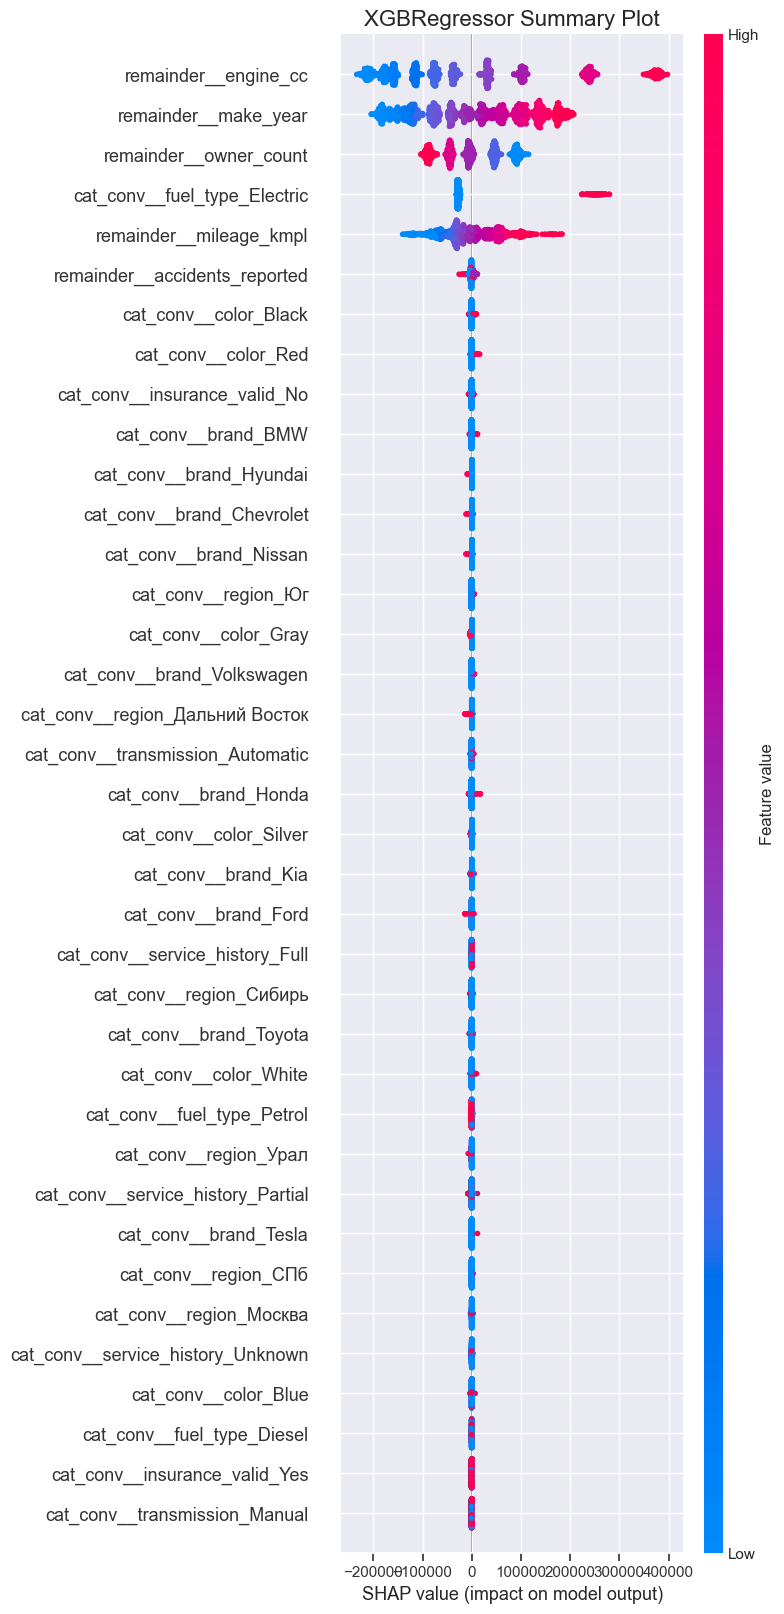

In [24]:
xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap = xgb_explainer.shap_values(X_xgb_val_pp)

plt.figure(figsize=(10, 8))
shap.summary_plot(xgb_shap, X_xgb_val_pp, show=False, max_display=40)
plt.title("XGBRegressor Summary Plot", fontsize=16)
plt.tight_layout()
plt.show()

- Самые важные признаки - объем двигателя, год выпуска, количество владельцев, пробег. Зависимость везде прямая, кроме количества владельцев.
- Электрокары стоят значительно дороже.
- Видно различие по маркам, цветам и регионам: 
    - на Дальнем востоке и Урале цена ниже; 
    - Tesla, Honda и BMW оцениваются дороже, Chevrolet, Nissan, Hyundai, Ford - дешевле; 
    - красные машины дороже, чем черные и белые, самые дешёвые - серые.

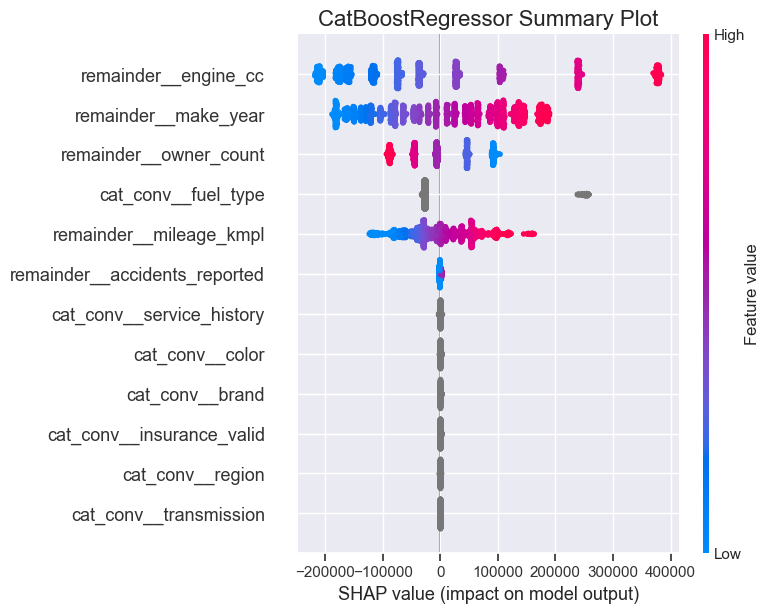

In [25]:
cb_explainer = shap.TreeExplainer(cb_model)
cb_shap = cb_explainer.shap_values(X_cat_val_pp)

plt.figure(figsize=(10, 8))
shap.summary_plot(cb_shap, X_cat_val_pp, show=False)
plt.title("CatBoostRegressor Summary Plot", fontsize=16)
plt.tight_layout()
plt.show()

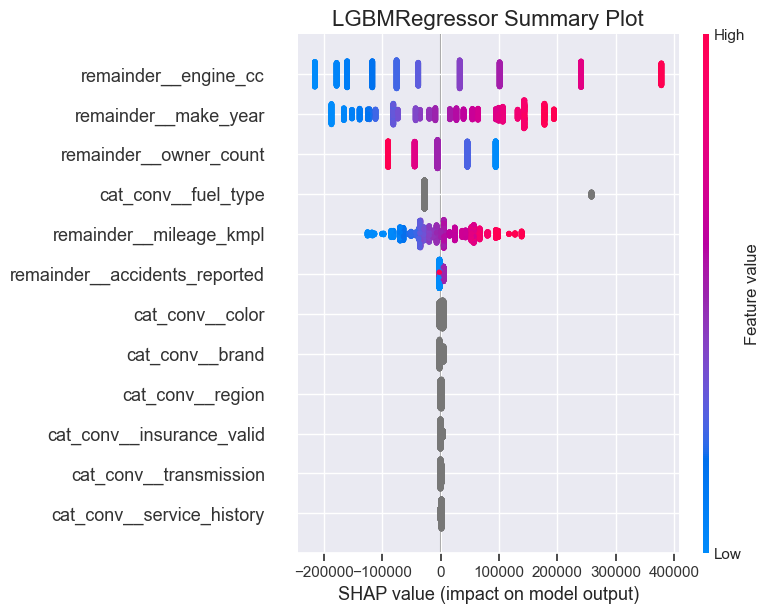

In [26]:
lgbm_explainer = shap.TreeExplainer(lgbm_model)
lgbm_shap = lgbm_explainer.shap_values(X_cat_val_pp)

plt.figure(figsize=(10, 8))
shap.summary_plot(lgbm_shap, X_cat_val_pp, show=False)
plt.title("LGBMRegressor Summary Plot", fontsize=16)
plt.tight_layout()
plt.show()

- Диаграммы для `CatBoostRegressor` и `LGBMRegressor` подтверждают выводы, сделанные для `XGBRegressor`.

### 6.2. Анализ бизнес-метрик

In [27]:
display(metrics[metrics.index.str.contains('pric') | (metrics.index.str.contains('MA'))])

,XGBRegressor,CatBoostRegressor,LGBMRegressor
MAE,79976.8906,79079.8300,79083.5953
MAPE,0.1506,0.1492,0.1488
Overpricing Rate,0.1355,0.1325,0.1315
Underpricing Rate,0.0695,0.0655,0.0685
Underpricing Loss,23286822.5938,21744709.3221,22278429.1783


- Худший результат по всем метрикам показывает `XGBRegressor` - в большую сторону она ошиблась в 13.6% случаях, в меньшую - в 7%. Суммарная упущенная выгода - 23.3 млн руб.
- `CatBoostRegressor` на 0.1% чаще выдает завышенную оценку, чем `LGBMRegressor`, а в меньшую сторону ошибается на 0.3% реже. Поскольку переоценка влечёт за собой прямые убытки, более предпочтительным является поведение модели `LGBMRegressor`.
- Средняя ошибка моделей `CatBoostRegressor` и `LGBMRegressor` составляет примерно 79080 р., для `CatBoostRegressor` - 14.92%, для `LGBMRegressor` - 14.88%.
- Более предпочтительной для внедрения является модель `LGBMRegressor`

### 6.3. Анализ по маркам автомобилей и регионам

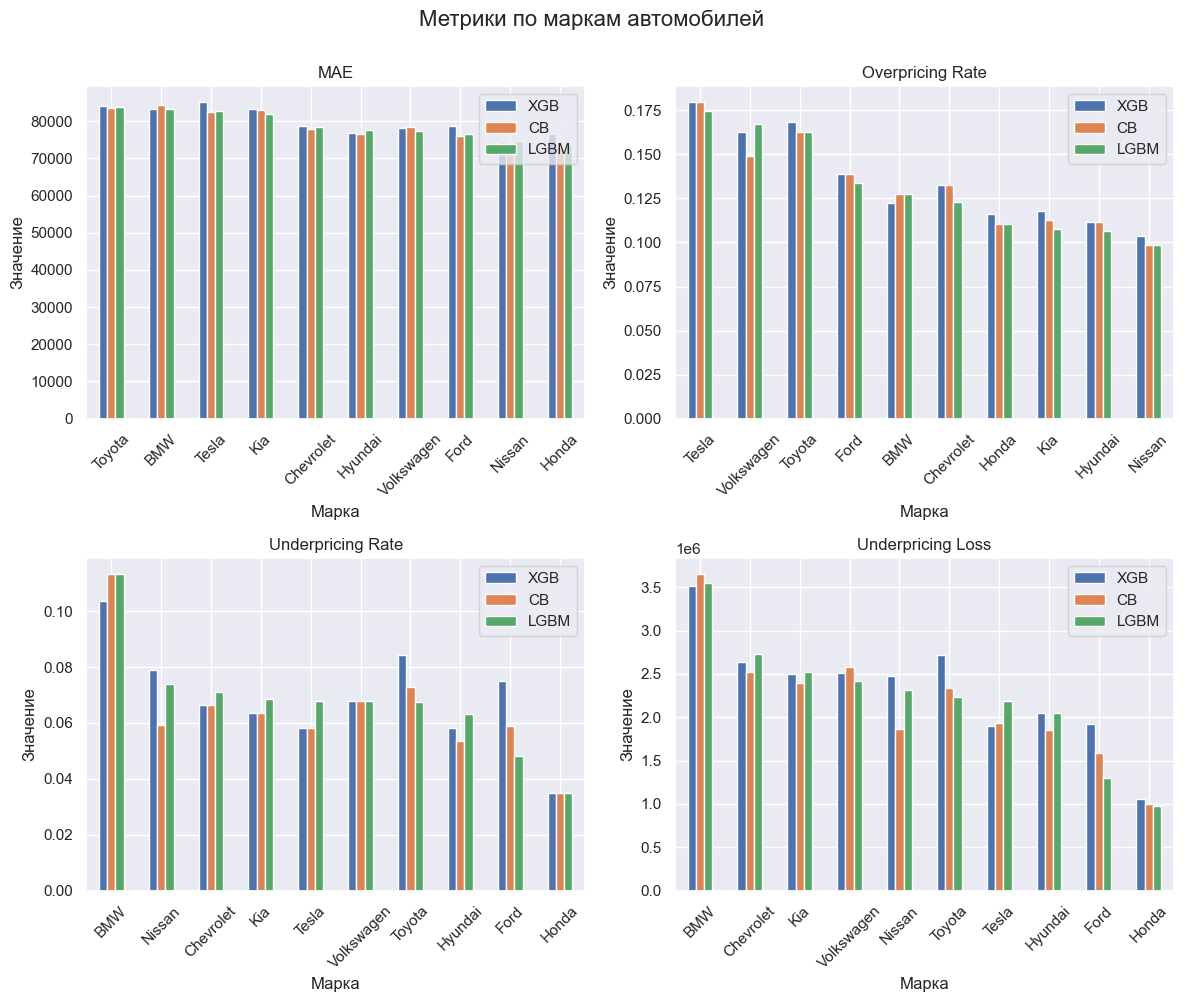

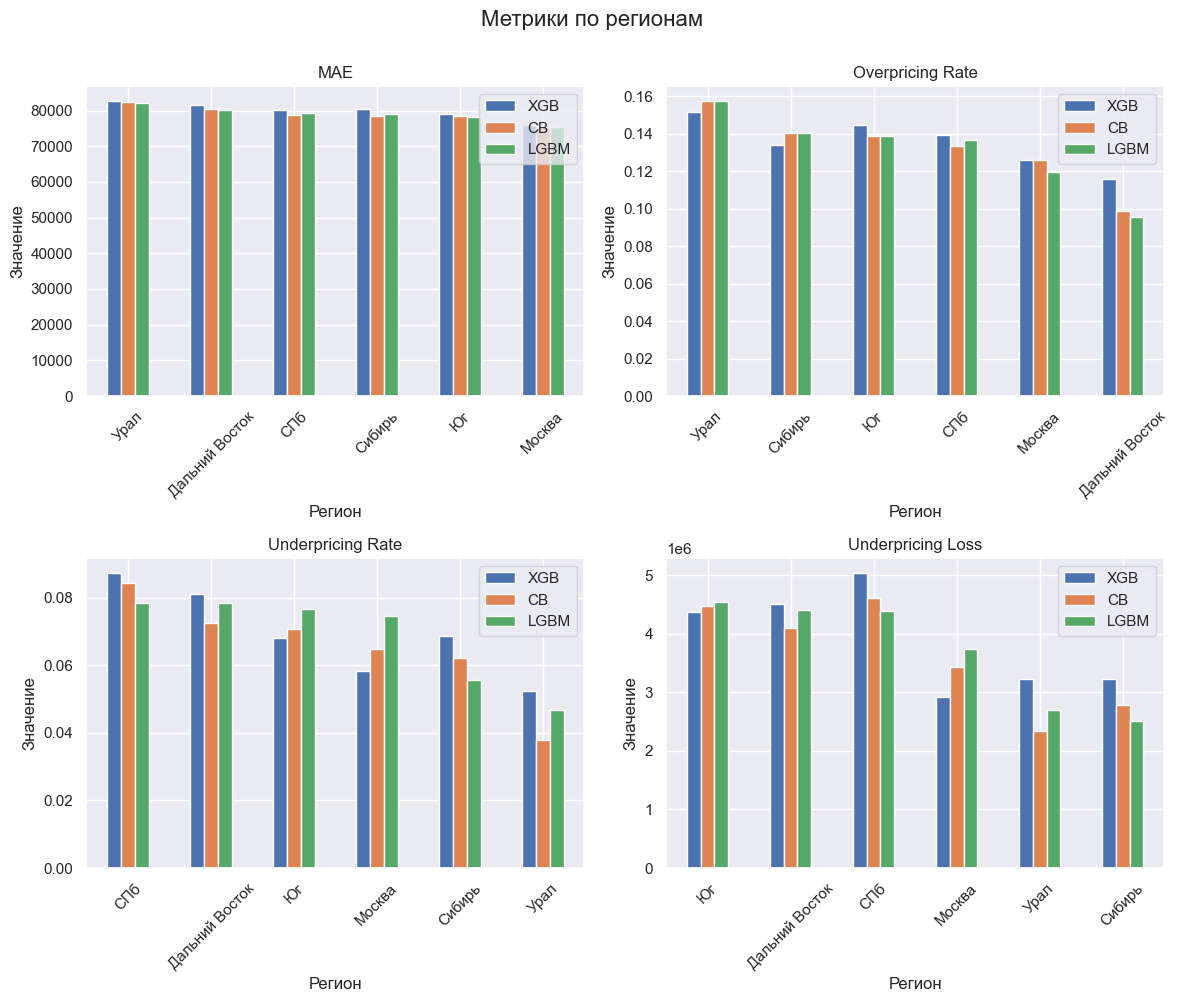

In [31]:
def pivot_metrics(X, y, y_preds, groupby, index):
    mae_dic = {}
    ovp_dic = {}
    undp_rate_dic = {}
    undp_dic = {}

    for val in X[groupby].unique():
        mask = X[groupby] == val
        metrics = [calc_metrics(y[mask], y_pred[mask]) for y_pred in y_preds]

        mae_dic[val] = [m['MAE'] for m in metrics] 
        ovp_dic[val] = [m['Overpricing Rate'] for m in metrics]
        undp_rate_dic[val] = [m['Underpricing Rate'] for m in metrics]
        undp_dic[val] = [m['Underpricing Loss'] for m in metrics]
    
    return (pd.DataFrame(mae_dic, index=index).T,
            pd.DataFrame(ovp_dic, index=index).T,
            pd.DataFrame(undp_rate_dic, index=index).T,
            pd.DataFrame(undp_dic, index=index).T)

brand_pivot = pivot_metrics(X_val, 
                            y_val, 
                            [y_xgb_val_pred, y_cb_val_pred, y_lgbm_val_pred], 
                            'brand', 
                            ['XGB', 'CB', 'LGBM'])

region_pivot = pivot_metrics(X_val, 
                             y_val, 
                             [y_xgb_val_pred, y_cb_val_pred, y_lgbm_val_pred], 
                             'region', 
                             ['XGB', 'CB', 'LGBM'])

brand_desc = [
    {'data': brand_pivot[0].sort_values(by='LGBM', ascending=False), 'title': "MAE", 
     'xlabel': "Марка", 'ylabel': 'Значение', 'rot': 45},
    {'data': brand_pivot[1].sort_values(by='LGBM', ascending=False), 'title': "Overpricing Rate", 
     'xlabel': "Марка", 'ylabel': 'Значение', 'rot': 45},
    {'data': brand_pivot[2].sort_values(by='LGBM', ascending=False), 'title': "Underpricing Rate", 
     'xlabel': "Марка", 'ylabel': 'Значение', 'rot': 45},
    {'data': brand_pivot[3].sort_values(by='LGBM', ascending=False), 'title': "Underpricing Loss", 
     'xlabel': "Марка", 'ylabel': 'Значение', 'rot': 45}
]

region_desc = [
    {'data': region_pivot[0].sort_values(by='LGBM', ascending=False), 'title': "MAE", 
     'xlabel': "Регион", 'ylabel': 'Значение', 'rot': 45},
    {'data': region_pivot[1].sort_values(by='LGBM', ascending=False), 'title': "Overpricing Rate", 
     'xlabel': "Регион", 'ylabel': 'Значение', 'rot': 45},
    {'data': region_pivot[2].sort_values(by='LGBM', ascending=False), 'title': "Underpricing Rate", 
     'xlabel': "Регион", 'ylabel': 'Значение', 'rot': 45},
    {'data': region_pivot[3].sort_values(by='LGBM', ascending=False), 'title': "Underpricing Loss", 
     'xlabel': "Регион", 'ylabel': 'Значение', 'rot': 45}
]
show_barplot_grid(brand_desc, "Метрики по маркам автомобилей")
show_barplot_grid(region_desc, "Метрики по регионам")

# **Часть 1. EDA (Экспресс-анализ данных)**

Проведите краткое исследование, чтобы лучше понимать данные.

**Задание 1.1:**

* Данные: загрузите `ds_s16_train_data.csv` (обучение) и `ds_s16_test_data.csv` (финальный тест). Обратите внимание на то, как прописать путь к данным: `/datasets/ds_s16_train_data.csv` и `/datasets/ds_s16_test_data.csv`
* Проведите краткий EDA: изучите распределение целевой переменной (`price_rub`), проверьте корреляции.

---

# **Часть 2. Предобработка**

На этом этапе подготовьте данные для честного соревнования библиотек. Помните: качество входных данных определяет предел точности самого мощного алгоритма.

**Задание 2.1:**

* Создайте одинаковые обучающие и валидационные наборы данных для всех трех библиотек.
* Подготовьте признаки для каждой библиотеки.
* Зафиксируйте тест: используйте файл `ds_s16_test_data.csv` как отложенную тестовую выборку.


# **Часть 3. Обучение моделей в разных библиотеках**

Проверьте, как алгоритмы работают из коробки. Это покажет их естественную предрасположенность к вашему набору данных до начала тонкой настройки.

**Задание 3.1:**

* Обучите XGBoost, CatBoost и LightGBM на стандартных настройках.
* Установите для всех моделей `random_state=42`. В качестве целевой функции используйте MAE.
* Обучите каждую модель
* Задача со звёздочкой: замерьте время обучения и предсказания (Wall time) с помощью `%%time` или модуля `time`.

**Задание 3.2: Сравнение метрик**

* Рассчитайте математические метрики: MAE, RMSE, $R^2$.
* Рассчитайте бизнес-риски: Overpricing Rate (>20%) и Underpricing Loss (>20%).
* Сформулируйте гипотезу: какая библиотека на этом этапе кажется наиболее безопасной для бюджета компании?

**Задача со звёздочкой: модель с использованием Quantile Loss (квантильной регрессии) в CatBoost**

Что нужно сделать:

* Выберите библиотеку `CatBoost`. Реализуйте осторожную модель через квантильный лосс.
* Вместо стандартной функции потерь (MAE) установите `loss_function='Quantile'`.
* Настройте параметр квантиля. Достаточно при инициализации модели указать: `'Quantile:alpha=значение'`. Протестируйте разные значения, выберите оптимальное.
* Сравните результаты этой осторожной модели с базовой (обученной с помощью MAE):
  1. Насколько снизился Overpricing Rate?
  2. Насколько при этом вырос Underpricing Loss?
  3. Готовы ли вы рекомендовать такую безопасную модель Артёму (CEO) вместо самой точной базовой (обученной с помощью MAE)?

---

# **Часть 4. Работа с параметрами модели (Тюнинг)**

Теперь ваша задача — заставить алгоритмы работать на пределе возможностей, подбирая ключи к их гиперпараметрам. Чтобы сравнение было объективным, используйте единую стратегию поиска для всех библиотек.

**Задание 4.1:**

* Настройте поиск в Optuna для каждой модели.
* Использьзуйте сетку параметров, предложенную в описании проекта:
  1. **Общая сетка для всех моделей:**
    * Скорость обучения (`learning_rate/eta`): от `0.01` до `0.1, log=True`.
    * Глубина дерева (`max_depth/depth`): от `3` до `10`.
    * Количество итераций (`n_estimators/iterations`): зафиксируйте в диапазоне `500–2000`.
  2. **Специфические параметры (регуляризация):**
  * Для XGBoost: добавьте параметры `gamma` (от `1e-8` до `1.0`) и `reg_lambda/reg_alpha`(от `1e-8` до `10.0`).
  * Для CatBoost: используйте `l2_leaf_reg` (от `1` до `10`).
  * Для LightGBM: добавьте `num_leaves` (от `20` до `256`) и `min_child_samples` (от `5` до `100`); `reg_alpha` и `reg_lambda` от `1e-8` до `1.0`.
  3. Не забудьте `"random_seed": 42` и `MAE` .

* Проведите поиск гиперпараметров с помощью Optuna.
---


# **Часть 5. Интерпретация и бизнес-анализ**

Модель должна быть прозрачной. Ваша задача — убедиться, что алгоритм принимает решения на основе рыночных факторов, а не случайных корреляций.

**Задание 5.1:**

* Постройте SHAP Summary Plot для оптимизированных моделей после поиска Optuna.
* Проанализируйте:
  1. Какие Топ-5 признаков вносят наибольший вклад в цену автомобиля?
  2. Совпадают ли выводы модели с бизнес-логикой?
  3. Как специфические признаки (например, color или insurance_valid) влияют на предсказание?

**Задание 5.2**

Используйте введённые метрики Overpricing Rate и Underpricing Loss:
* Рассчитайте долю завышений и недооценок для каждой модели.
* Сравните модели не только по MAE и RMSE, но и по бизнес-рискам.

**Задание 5.3**

* Проанализируйте ошибки в разрезе категорий (марки автомобилей и макро-регионов).
* Выявите марки машин и регионы, где риск ошибки высок — это зоны, где в будущем потребуется ручная проверка экспертом.

---

# **Часть 6. Финальная проверка**

Момент истины. На этом этапе вы должны подтвердить надежность выбранного решения на данных, которые модель никогда не видела, и дать обоснованную рекомендацию бизнесу.

**Задание 6.1**

* Выберите лучшую модель и прогоните её через `ds_s16_test_data.csv`.
* Сформируйте итоговый результат на тестовой выборке. Проверьте, нет ли переобучения.

 # **Часть 7. Описание выводов и финальный вердикт**

**Задание 7.1**

Заполните краткую аналитическую записку на основе ваших данных.

**АНАЛИТИЧЕСКАЯ ЗАПИСКА ПО ПРОЕКТУ AUTOVALUE AI:**

1. Рекомендованная модель: [Название вашей лучшей модели, например]

2. Точность оценки: в среднем модель ошибается на [Ваше MAE] руб. Коэффициент детерминации равен[Ваше $R^2$], что подтверждает высокую надёжность прогнозов.

3. Безопасность бюджета: риск опасной переплаты (Overpricing >20%) зафиксирован на уровне [Ваш %]. Это позволяет стартапу сохранять маржинальность при выкупе.

4. Упущенная выгода: можем терять до [Сумма Underpricing Loss] руб. в месяц из-за занижения цены. Рекомендуется ручной пересмотр для премиум-сегмента.

5. Зоны риска: модель наиболее нестабильна в регионе [Ваш проблемный регион] и на марках [Ваши проблемные марки].

6. Какие гиперпараметры следует зафиксировать для интеграции в мобильное приложение.

---